In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns

from typing import Tuple

In [4]:
def get_results_and_preview(results_path: str, resample_interval: str) -> Tuple[list, list]:
    df = pd.read_csv(results_path)
    avg_flink = (
        df.iloc[-1]["number_of_rows_finished"] / df.iloc[-1]["time_from_start"]
    )
    print("actual throughput:", avg_flink)

    df['time_from_start'] = pd.to_timedelta(df['time_from_start'], unit='s')
    df.set_index("time_from_start", inplace=True)
    resampled = df['number_of_rows_finished'].resample(resample_interval).mean().ffill()
    time_vals = resampled.index.total_seconds()
    row_vals = resampled

    tput_vals = row_vals.diff() / time_vals.diff()
    tput_vals = tput_vals.fillna(0)
    filled_time_vals_rd = []
    filled_tput_vals_rd = []

    for i in np.arange(0, int(time_vals[0]), 5):
        filled_time_vals_rd.append(i)
        filled_tput_vals_rd.append(0)

    filled_time_vals_rd.extend(time_vals)
    filled_tput_vals_rd.extend(tput_vals)

    print("Smoothed throughput: ", np.average(filled_tput_vals_rd))

    filled_time_vals_rd = [item / 60 for item in filled_time_vals_rd]
    plt.plot(filled_time_vals_rd, filled_tput_vals_rd)
    plt.show()
    return (filled_time_vals_rd, filled_tput_vals_rd)

actual throughput: 111.57976725365229
Smoothed throughput:  109.83432478632479


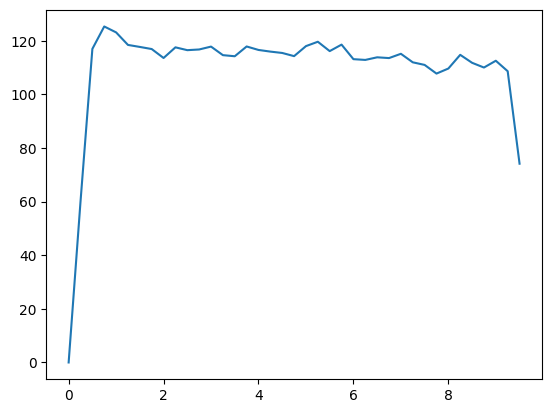

In [7]:
timestamp_radar_dynamic, tput_radar_dynamic = get_results_and_preview('/Users/guyile/Desktop/research/ray-data-yilegu/plot/video-inference/radar-dynamic-2.csv', '15s')

actual throughput: 108.29403169783235
Smoothed throughput:  106.53391954022989


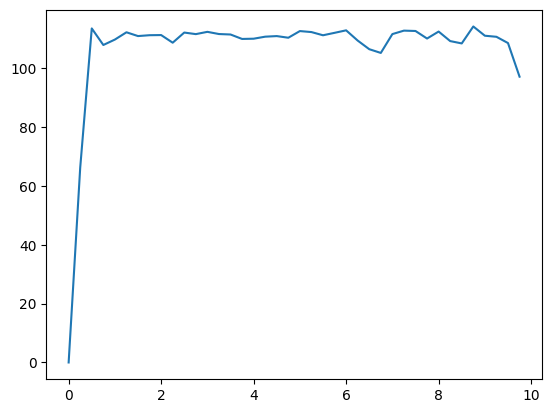

In [9]:
timestamp_radar_static, tput_radar_static = get_results_and_preview('/Users/guyile/Desktop/research/ray-data-yilegu/plot/video-inference/radar-static-3.csv', '15s')

actual throughput: 44.222420524506354
Smoothed throughput:  42.762666666666675


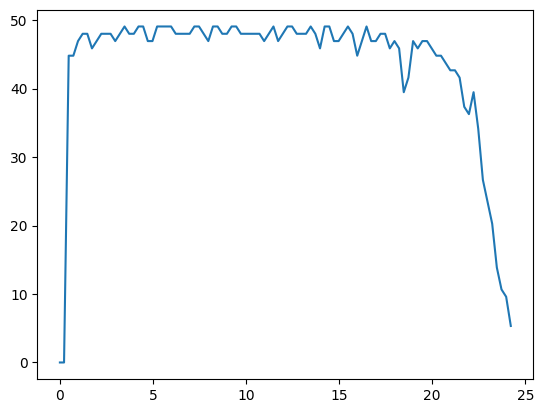

In [10]:
timestamp_flink, tput_flink = get_results_and_preview('/Users/guyile/Desktop/research/ray-data-yilegu/plot/video-inference/flink_video_inference.csv', '15s')

actual throughput: 89.01656892287535
Smoothed throughput:  87.76870748299321


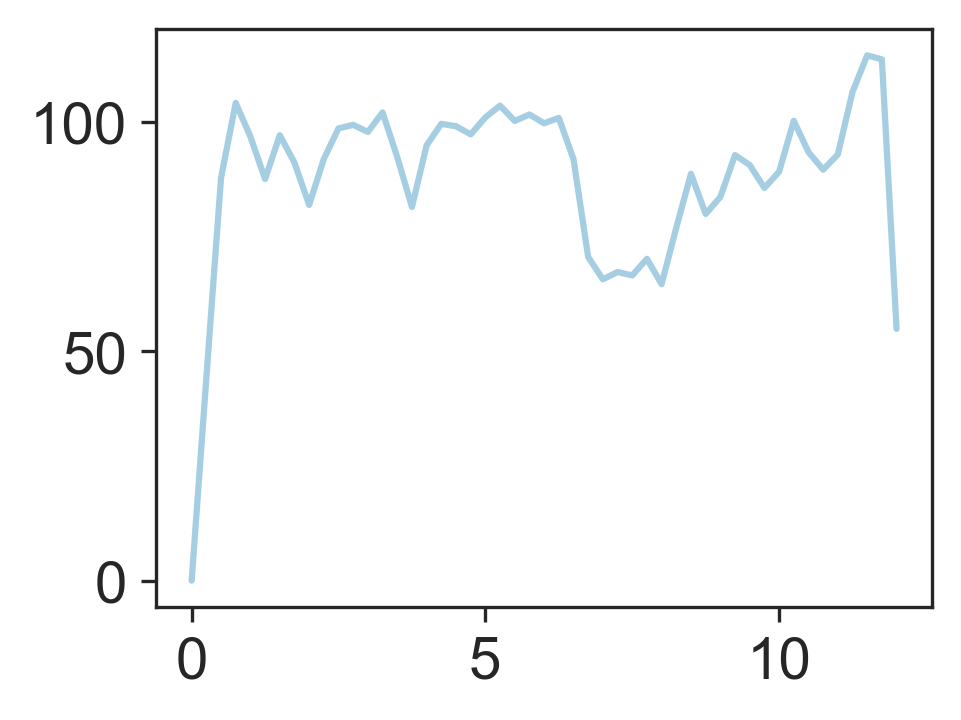

In [37]:
timestamp_radar_rr, tput_radar_rr = get_results_and_preview('/Users/guyile/Desktop/research/ray-data-yilegu/plot/video-inference/radar-round-robin.csv', '15s')

actual throughput: 9.232445293178474
Smoothed throughput:  4.809566517189835


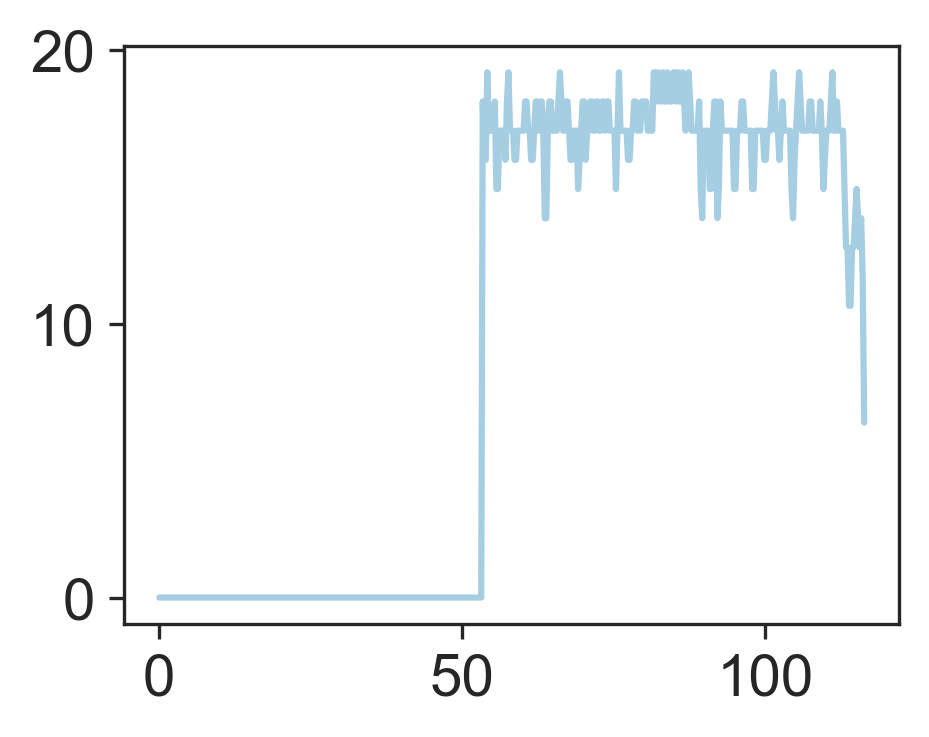

In [14]:
timestamp_spark, tput_spark = get_results_and_preview('/Users/guyile/Desktop/research/ray-data-yilegu/plot/video-inference/spark-transformed.csv', '15s')

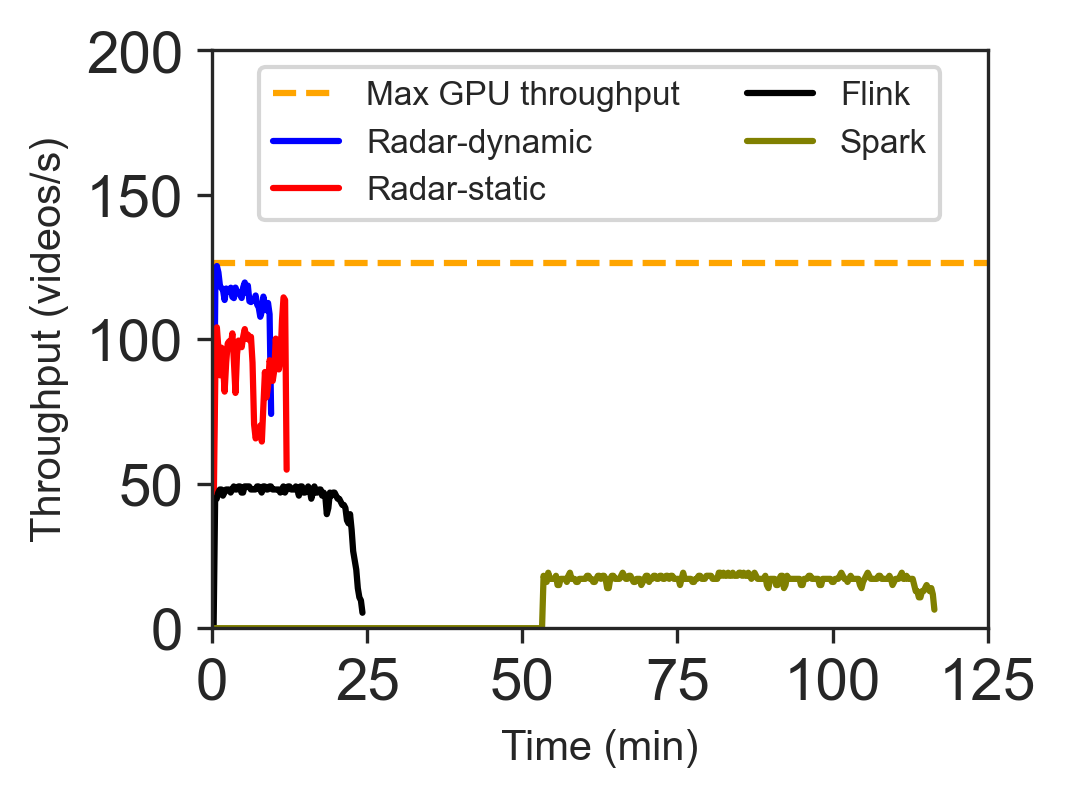

In [36]:
FIGRATIO = 3 / 4
FIGWIDTH = 3.335  # inches
FIGHEIGHT = FIGWIDTH * FIGRATIO
FIGSIZE = (FIGWIDTH, FIGHEIGHT)
BIG_SIZE = 14

INFERENCE_TPUT_MEAN = 31.570071340125125 * 4

COLORS = sns.color_palette("Paired")
sns.set_style("ticks")
sns.set_palette(COLORS)

plt.rcParams.update(
    {
        "figure.figsize": FIGSIZE,
        "figure.dpi": 300,
        "text.usetex": False,
    }
)
plt.rc("font", size=BIG_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=BIG_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=BIG_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=BIG_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=BIG_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=BIG_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIG_SIZE)  # fontsize of the figure title

fig, ax = plt.subplots()
ax.axhline(y=INFERENCE_TPUT_MEAN, color="orange", linestyle="--", label="Max GPU throughput")

ax.plot(timestamp_radar_dynamic, tput_radar_dynamic, label='Radar-dynamic', color='blue')
# ax.plot(timestamp_radar_static, tput_radar_static, label='Radar-static', color='red')
ax.plot(timestamp_radar_rr, tput_radar_rr, label='Radar-static', color='red')
ax.plot(timestamp_flink, tput_flink, label='Flink', color='black')
ax.plot(timestamp_spark, tput_spark, label='Spark', color='olive')

plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))

plt.xlabel("Time (min)", fontsize=10)
plt.ylabel("Throughput (videos/s)", fontsize=10)
plt.xlim(0, 125)
plt.ylim(0, 200)
handles, labels = plt.gca().get_legend_handles_labels()

# Reorder the legend
# order = [3, 1, 4, 2, 0, 5, 6]
order = [0, 1, 2, 3, 4]
ordered_handles = [handles[i] for i in order]
ordered_labels = [labels[i] for i in order]
plt.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    fontsize=8.,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.00),   # shift a bit upward if needed
    ncol=2,                       # two columns
    frameon=True
)
# plt.legend(ordered_handles, ordered_labels, fontsize=8.)
# plt.legend()

plt.savefig("video-inference.pdf", bbox_inches='tight')

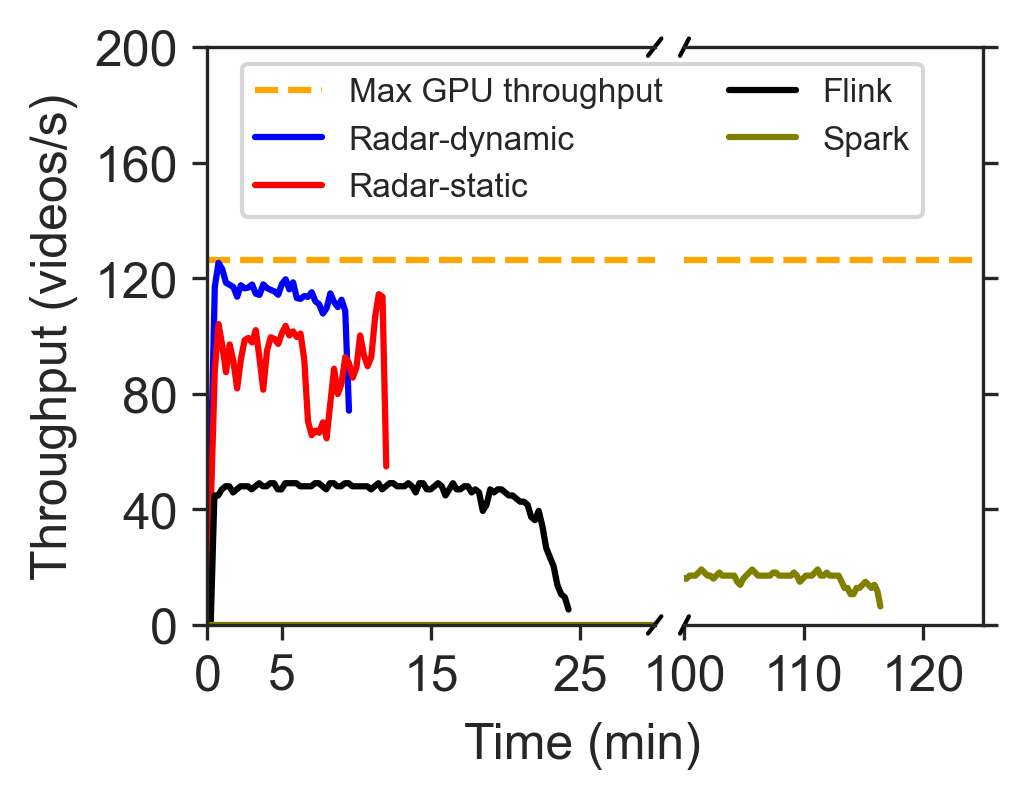

In [69]:
FIGRATIO = 3 / 4
FIGWIDTH = 3.335  # inches
FIGHEIGHT = FIGWIDTH * FIGRATIO
FIGSIZE = (FIGWIDTH, FIGHEIGHT)
BIG_SIZE = 12

INFERENCE_TPUT_MEAN = 31.570071340125125 * 4

COLORS = sns.color_palette("Paired")
sns.set_style("ticks")
sns.set_palette(COLORS)

plt.rcParams.update(
    {
        "figure.figsize": FIGSIZE,
        "figure.dpi": 300,
        "text.usetex": False,
        "font.size": BIG_SIZE,        # <- global font size
        "axes.titlesize": BIG_SIZE,
        "axes.labelsize": BIG_SIZE,
        "xtick.labelsize": BIG_SIZE,
        "ytick.labelsize": BIG_SIZE,
        "legend.fontsize": BIG_SIZE,
        "figure.titlesize": BIG_SIZE,
    }
)

# --- broken x-axis: two panels sharing y ---
fig, (ax1, ax2) = plt.subplots(
    1, 2, sharey=True,
    gridspec_kw={"width_ratios": [3, 2], "wspace": 0.08}
)

# Common plotter to avoid duplication
def plot_all(ax):
    ax.axhline(y=INFERENCE_TPUT_MEAN, color="orange", linestyle="--", label="Max GPU throughput")
    ax.plot(timestamp_radar_dynamic, tput_radar_dynamic, label='Radar-dynamic', color='blue')
    ax.plot(timestamp_radar_rr, tput_radar_rr, label='Radar-static', color='red')
    ax.plot(timestamp_flink, tput_flink, label='Flink', color='black')
    ax.plot(timestamp_spark, tput_spark, label='Spark', color='olive')

# Left: 0–30
plot_all(ax1)
ax1.set_xlim(0, 30)
ax1.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6))
ax1.set_ylabel("Throughput (videos/s)")

# Right: 100–125
plot_all(ax2)
ax2.set_xlim(100, 125)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))

# Hide spines and add diagonal break marks
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax1.tick_params(labelright=False)
ax2.yaxis.tick_right()

# Diagonal slashes
d = 0.015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1.0)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

# X-ticks without overlap
ax1.set_xticks([0, 5, 15, 25])
ax2.set_xticks([100, 110, 120])

# Shared xlabel
fig.text(0.5, -0.05, "Time (min)", ha="center", va="center")

# Legend
handles, labels = ax2.get_legend_handles_labels()
order = [0, 1, 2, 3, 4]
fig.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.88),
    ncol=2,
    frameon=True,
    fontsize=8,
    
)

plt.ylim(0, 200)
plt.savefig("video-inference-cut-off.pdf", bbox_inches='tight')


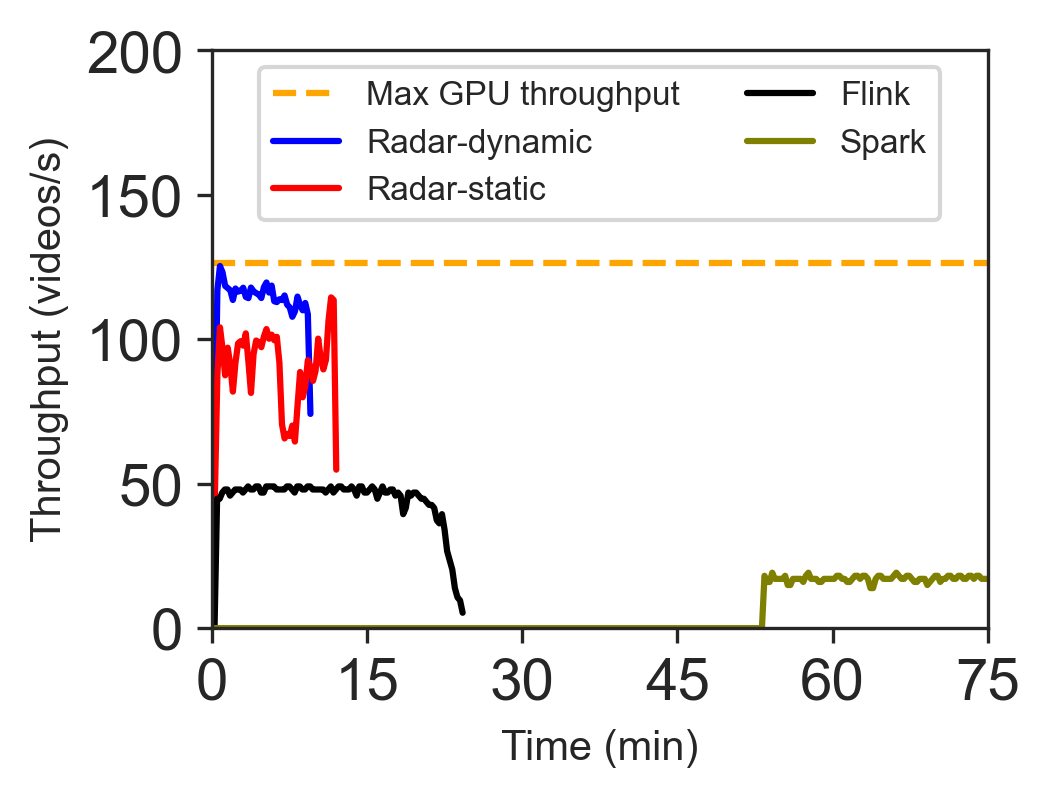

In [68]:
FIGRATIO = 3 / 4
FIGWIDTH = 3.335  # inches
FIGHEIGHT = FIGWIDTH * FIGRATIO
FIGSIZE = (FIGWIDTH, FIGHEIGHT)
BIG_SIZE = 14

INFERENCE_TPUT_MEAN = 31.570071340125125 * 4

COLORS = sns.color_palette("Paired")
sns.set_style("ticks")
sns.set_palette(COLORS)

plt.rcParams.update(
    {
        "figure.figsize": FIGSIZE,
        "figure.dpi": 300,
        "text.usetex": False,
    }
)
plt.rc("font", size=BIG_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=BIG_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=BIG_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=BIG_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=BIG_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=BIG_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIG_SIZE)  # fontsize of the figure title

fig, ax = plt.subplots()
ax.axhline(y=INFERENCE_TPUT_MEAN, color="orange", linestyle="--", label="Max GPU throughput")

ax.plot(timestamp_radar_dynamic, tput_radar_dynamic, label='Radar-dynamic', color='blue')
# ax.plot(timestamp_radar_static, tput_radar_static, label='Radar-static', color='red')
ax.plot(timestamp_radar_rr, tput_radar_rr, label='Radar-static', color='red')
ax.plot(timestamp_flink, tput_flink, label='Flink', color='black')
ax.plot(timestamp_spark, tput_spark, label='Spark', color='olive')

plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))

plt.xlabel("Time (min)", fontsize=10)
plt.ylabel("Throughput (videos/s)", fontsize=10)
plt.xlim(0, 75)
plt.ylim(0, 200)
handles, labels = plt.gca().get_legend_handles_labels()

# Reorder the legend
# order = [3, 1, 4, 2, 0, 5, 6]
order = [0, 1, 2, 3, 4]
ordered_handles = [handles[i] for i in order]
ordered_labels = [labels[i] for i in order]
plt.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    fontsize=8.,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.00),   # shift a bit upward if needed
    ncol=2,                       # two columns
    frameon=True
)
# plt.legend(ordered_handles, ordered_labels, fontsize=8.)
# plt.legend()

plt.savefig("video-inference-0-75.pdf", bbox_inches='tight')